In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# Project paths
PROJECT = Path.home() / "Projects/xenium_lung"

VIS_DIR = PROJECT / "results/xenium_5k/visualization"

COORDINATES_FILE = VIS_DIR / "cell_coordinates.parquet"
CLUSTERS_FILE = VIS_DIR / "cluster_labels.csv"

In [3]:
coordinates = pd.read_parquet(COORDINATES_FILE)
clusters = pd.read_csv(CLUSTERS_FILE)

print("Coordinates:")
print(coordinates.shape)
print(coordinates.head())

print("\nClusters:")
print(clusters.shape)
print(clusters.head())

Coordinates:
(266179, 3)
      cell_id           x            y
0  aaaaadnb-1  822.469055  5111.537598
1  aaaabalp-1  843.901428  5149.261230
2  aaaadfei-1  831.219421  5133.179199
3  aaaadjia-1  839.742981  5159.693848
4  aaaafglb-1  784.250916  5143.785645

Clusters:
(266179, 2)
      cell_id  group
0  aaaaadnb-1      0
1  aaaabalp-1      0
2  aaaadfei-1      1
3  aaaadjia-1      0
4  aaaafglb-1      1


In [4]:
cells = coordinates.merge(
    clusters,
    on="cell_id",
    how="left",
    validate="one_to_one"
)

print("Merged data:", cells.shape)
print(cells.head())

Merged data: (266179, 4)
      cell_id           x            y  group
0  aaaaadnb-1  822.469055  5111.537598      0
1  aaaabalp-1  843.901428  5149.261230      0
2  aaaadfei-1  831.219421  5133.179199      1
3  aaaadjia-1  839.742981  5159.693848      0
4  aaaafglb-1  784.250916  5143.785645      1


In [5]:
print("Unique cell IDs:", cells["cell_id"].is_unique)
print("Missing coordinates:", cells[["x", "y"]].isna().any(axis=1).sum())
print("Missing cluster labels:", cells["group"].isna().sum())

print("\nNumber of clusters:", cells["group"].nunique())
print("Cluster IDs:", sorted(cells["group"].dropna().unique()))

Unique cell IDs: True
Missing coordinates: 0
Missing cluster labels: 0

Number of clusters: 20
Cluster IDs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [6]:
print("X range:", cells["x"].min(), "→", cells["x"].max())
print("Y range:", cells["y"].min(), "→", cells["y"].max())

X range: 9.384281158447266 → 11467.05078125
Y range: 145.14759826660156 → 7783.51318359375


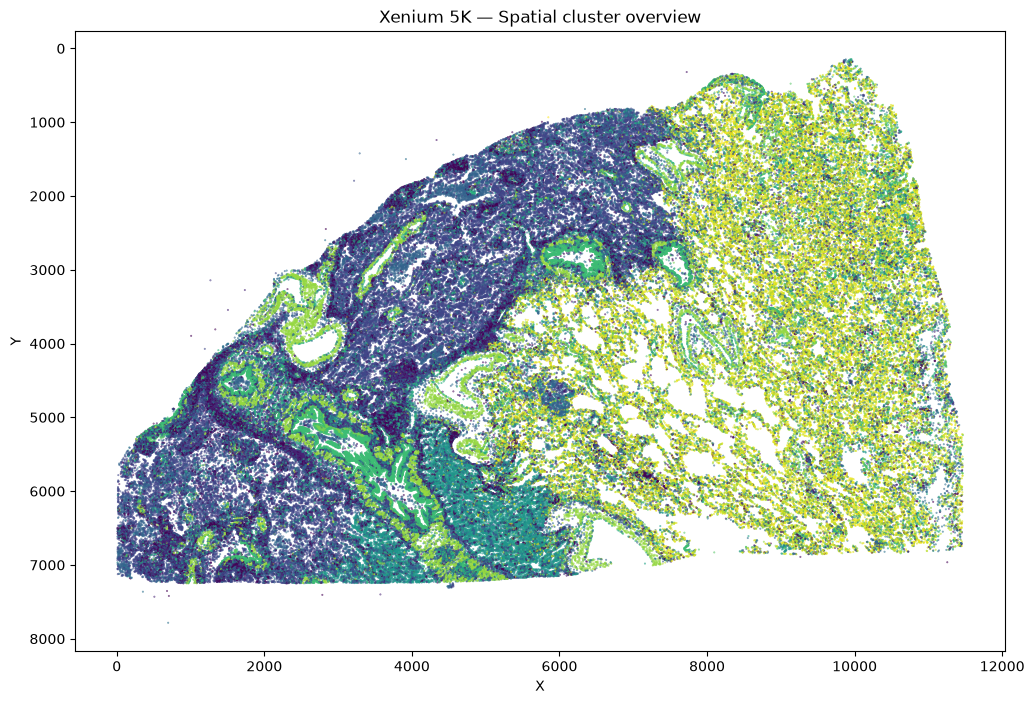

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    cells["x"],
    cells["y"],
    c=cells["group"],
    s=0.2,
    alpha=0.7,
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Xenium 5K — Spatial cluster overview")

plt.show()

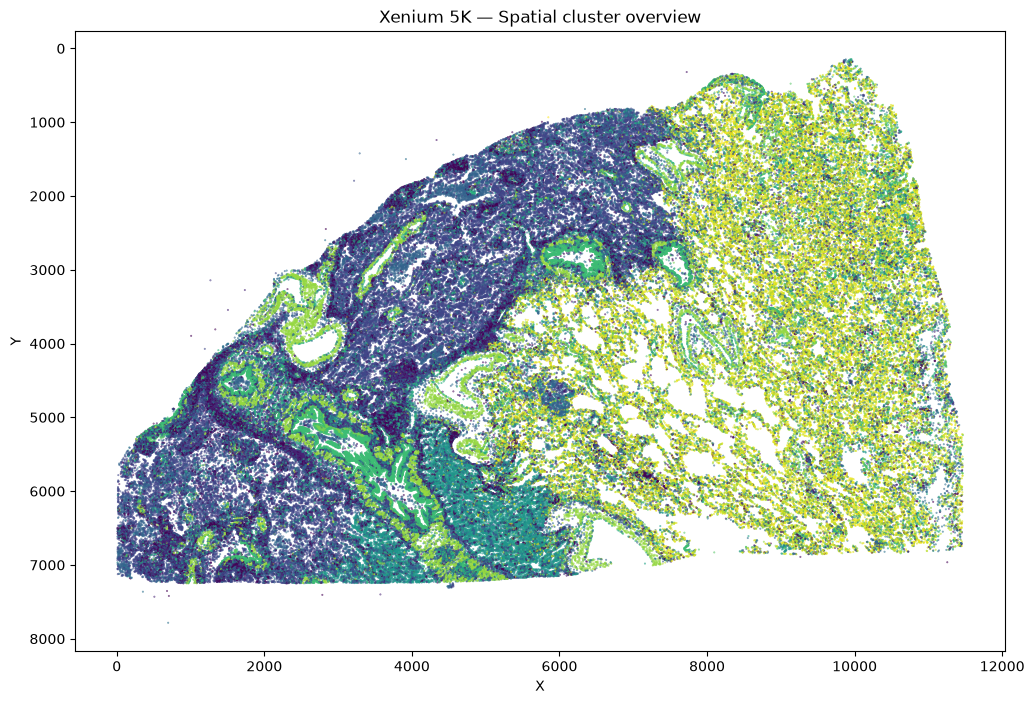

In [8]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    cells["x"],
    cells["y"],
    c=cells["group"],
    s=0.2,
    alpha=0.7,
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Xenium 5K — Spatial cluster overview")

plt.show()

In [14]:
cluster_counts = (
    cells["group"]
    .value_counts()
    .sort_index()
)

print(cluster_counts)
print("\nTotal cells:", cluster_counts.sum())

group
0     31717
1     10247
2      9740
3      9999
4     27406
5     19480
6     23651
7     14954
8      1942
9      3902
10     9270
11     2326
12    19053
13    11179
14     8752
15      984
16    15938
17    14186
18    22537
19     8916
Name: count, dtype: int64

Total cells: 266179


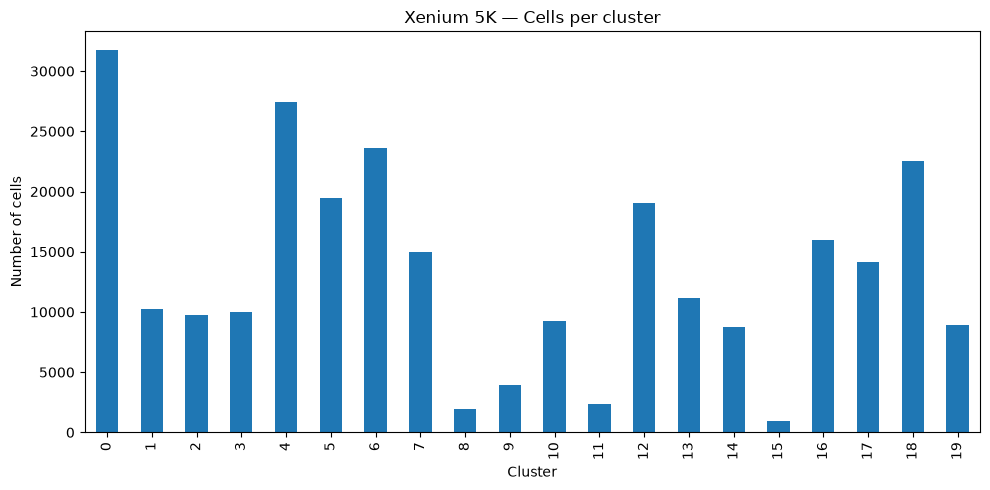

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

cluster_counts.plot(
    kind="bar",
    ax=ax,
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Number of cells")
ax.set_title("Xenium 5K — Cells per cluster")

plt.tight_layout()
plt.show()